In [15]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
data = pd.read_csv("twentyscience.csv")
df = data.copy()


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          130 non-null    int64  
 1   album_release_date  130 non-null    object 
 2   album_release_year  130 non-null    int64  
 3   danceability        130 non-null    float64
 4   energy              130 non-null    float64
 5   key                 130 non-null    int64  
 6   loudness            130 non-null    float64
 7   mode                130 non-null    int64  
 8   speechiness         130 non-null    float64
 9   acousticness        130 non-null    float64
 10  instrumentalness    130 non-null    float64
 11  liveness            130 non-null    float64
 12  valence             130 non-null    float64
 13  tempo               130 non-null    float64
 14  time_signature      130 non-null    int64  
 15  disc_number         130 non-null    int64  
 16  duration

In [18]:
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna()
df = df.drop_duplicates()
plt.style.use('ggplot')

In [19]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [20]:
df.sample(n=25)

,album_release_date,album_release_year,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,...,duration_ms,explicit,is_local,track_name,track_number,type,album_name,key_name,mode_name,key_mode
109,2013-01-08,2013,0.684,0.858,1,-4.266,1,0.0342,0.006940,0.000167,...,273335,False,False,Guns for Hands,10,track,Vessel (with Bonus Tracks),C#,major,C# major
24,2018-10-05,2018,0.506,0.379,4,-11.640,0,0.0334,0.726000,0.004580,...,280493,False,False,Leave the City,14,track,Trench,E,minor,E minor
40,2013-06-18,2013,0.427,0.415,4,-10.818,0,0.0479,0.009750,0.022100,...,333420,False,False,Ode to Sleep - Live from SXSW,2,track,Spotify Sessions,E,minor,E minor
129,2009-12-29,2009,0.753,0.421,7,-6.988,1,0.0551,0.103000,0.000040,...,345506,False,False,Isle Of Flightless Birds,14,track,Twenty One Pilots,G,major,G major
104,2013-01-08,2013,0.766,0.519,9,-7.355,0,0.0366,0.098000,0.000000,...,267720,False,False,Car Radio,5,track,Vessel (with Bonus Tracks),A,minor,A minor
105,2013-01-08,2013,0.780,0.716,6,-4.551,0,0.0439,0.048900,0.000006,...,253680,False,False,Semi-Automatic,6,track,Vessel (with Bonus Tracks),F#,minor,F# minor
123,2009-12-29,2009,0.501,0.328,0,-8.329,1,0.0255,0.612000,0.000000,...,217000,False,False,Oh Ms Believer,8,track,Twenty One Pilots,C,major,C major
101,2013-01-08,2013,0.608,0.776,11,-3.635,1,0.0511,0.241000,0.000000,...,263733,False,False,Holding on to You,2,track,Vessel (with Bonus Tracks),B,major,B major
39,2013-06-18,2013,0.633,0.140,10,-26.945,0,0.8770,0.942000,0.000000,...,28787,False,False,Intro - Live from SXSW,1,track,Spotify Sessions,A#,minor,A# minor
87,2013-01-08,2013,0.426,0.759,6,-6.644,1,0.0446,0.025300,0.000110,...,370808,False,False,Trees - Live at the LC Pavilion,14,track,Vessel,F#,major,F# major


## Analisis

In [25]:
df.groupby(by='album_name')["duration_ms"].mean().sort_values(ascending=False).round(2)



album_name
Spotify Sessions              283606.43
Twenty One Pilots             265956.86
Vessel (with Bonus Tracks)    248388.56
Trench                        240691.14
Blurryface                    224531.14
Scaled And Icy                205696.00
Vessel                        195512.17
Name: duration_ms, dtype: float64

Text(0.5, 0, 'Album')

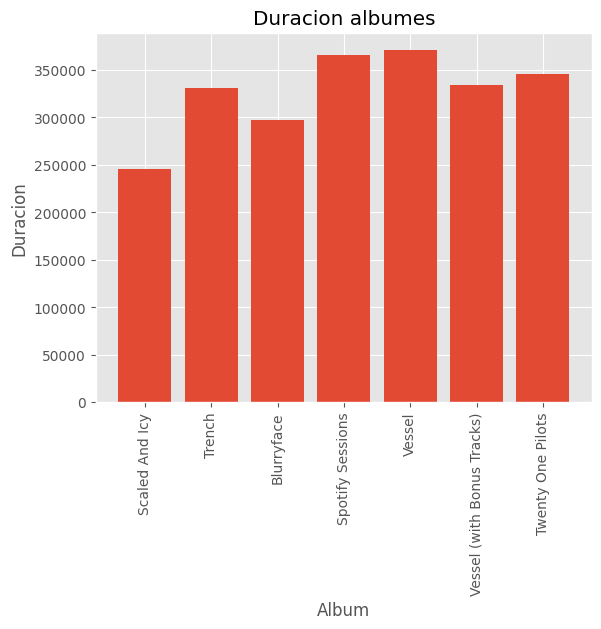

In [33]:
bar = plt.bar(df['album_name'],df['duration_ms'])
xticks = plt.xticks(rotation=90)
plt.title("Duracion albumes")
plt.ylabel('Duracion')
plt.xlabel('Album')

In [22]:
df.groupby(by='album_name')["tempo"].mean().sort_values(ascending=False).round(2)

album_name
Vessel (with Bonus Tracks)    127.60
Scaled And Icy                125.89
Twenty One Pilots             122.82
Blurryface                    122.27
Trench                        114.76
Vessel                        112.92
Spotify Sessions               91.75
Name: tempo, dtype: float64

In [23]:
df[['track_name','danceability','album_name']].sort_values(by="danceability",ascending =False).drop_duplicates()

,track_name,danceability,album_name
108,Fake You Out,0.840,Vessel (with Bonus Tracks)
66,Fake You Out,0.840,Vessel
117,Fall Away,0.816,Twenty One Pilots
65,The Run and Go,0.798,Vessel
107,The Run and Go,0.798,Vessel (with Bonus Tracks)
...,...,...,...
40,Ode to Sleep - Live from SXSW,0.427,Spotify Sessions
87,Trees - Live at the LC Pavilion,0.426,Vessel
31,The Judge,0.423,Blurryface
128,Before You Start Your Day,0.363,Twenty One Pilots


Text(0.5, 1.0, 'Mapa de densidad hexagonal: Tempo vs bailable')

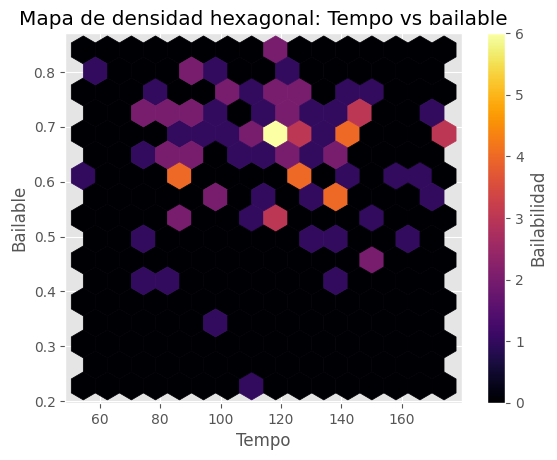

In [42]:
plt.hexbin(df['tempo'],df['danceability'],gridsize=15,cmap='inferno')
plt.colorbar(label='Bailabilidad')
plt.xlabel('Tempo')
plt.ylabel('Bailable')
plt.title('Mapa de densidad hexagonal: Tempo vs bailable')

Text(0.5, 1.0, 'Historigrama intensidad sonora')

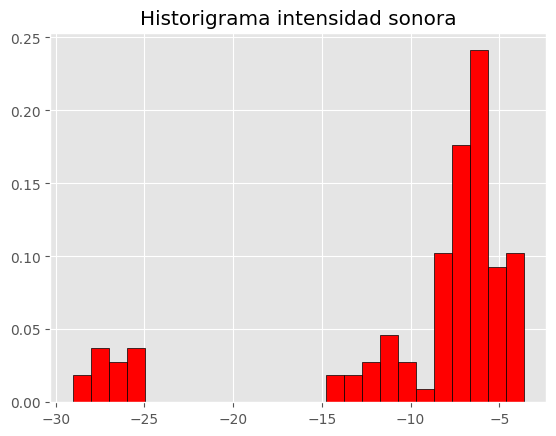

In [48]:
plt.hist(df['loudness'],bins=25,color='red',edgecolor='black',density=True)
plt.title('Historigrama intensidad sonora')